# Q1 : Circle Detection via LoG Scale-Space

**Goal:** Detect circular blobs (sunflowers) using Laplacian of Gaussian (LoG) in a multi-scale pyramid and 3D non-maximum suppression across (x, y, sigma).  
**No Hough transform** allowed.

**Inputs:**
- `images/the_berry_farms_sunflower_field.jpeg`

**Outputs:**
- Printed sigma range used
- List of the largest circles (center, radius)
- Visualization with detected circles overlaid on the image


In [236]:
import os
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 8)
plt.rcParams["axes.grid"] = False

# Paths
DATA = Path("../data")
RESULTS = Path("../results/q1")
RESULTS.mkdir(parents=True, exist_ok=True)

# Image path
IMG_PATH = DATA / "the_berry_farms_sunflower_field.jpeg"

# Scale-space parameters
SIGMA_MIN = 0.9
SIGMA_MAX = 2.1
NUM_SCALES = 5
BLOB_THRESH = 0.38

## Helper Functions

In [237]:
def apply_log_filter(image, sigma):
    """Apply Laplacian of Gaussian filter to image at given sigma."""
    smoothed = cv.GaussianBlur(image, (0, 0), sigma)
    log_response = cv.Laplacian(smoothed, cv.CV_64F)
    return np.abs(log_response)


def create_blob_mask(blob_response, threshold_ratio):
    """Create binary mask by thresholding blob response."""
    threshold_value = threshold_ratio * np.max(blob_response)
    return (blob_response > threshold_value).astype(np.uint8)


def extract_blob_circles(contours):
    """Convert valid contours to circle representations (center, radius)."""
    circles = []
    for contour in contours:
        if len(contour) >= 5:  # Minimum points needed for minEnclosingCircle
            center, radius = cv.minEnclosingCircle(contour)
            center_int = (int(center[0]), int(center[1]))
            radius_int = int(radius)
            circles.append((center_int, radius_int))
    return circles


def detect_blobs_at_scale(image, sigma, threshold_ratio):
    """Detect blobs at a specific scale and return circle parameters with sigma."""
    # Get LoG response
    response = apply_log_filter(image, sigma)

    # Create binary mask
    mask = create_blob_mask(response, threshold_ratio)

    # Find contours
    contours, _ = cv.findContours(
        mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Extract circles from contours
    circles = extract_blob_circles(contours)

    # Attach sigma to each detection
    return [(center, radius, sigma) for center, radius in circles]

## Blob Detection With Different Sigmas

In [238]:
# Load image and convert to grayscale
img = cv.imread(str(IMG_PATH), cv.IMREAD_REDUCED_COLOR_4)
if img is None:
    raise FileNotFoundError(f"Image not found at {IMG_PATH}")

gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Main blob detection parameters
sigma_range = np.linspace(SIGMA_MIN, SIGMA_MAX, NUM_SCALES)
blob_threshold = BLOB_THRESH

# Store all detected blobs across scales
all_detections = []

# Process each scale
for sigma_val in sigma_range:
    print(f"Processing scale with sigma = {sigma_val:.2f}")
    scale_detections = detect_blobs_at_scale(gray_img, sigma_val, blob_threshold)
    all_detections.extend(scale_detections)

Processing scale with sigma = 0.90
Processing scale with sigma = 1.20
Processing scale with sigma = 1.50
Processing scale with sigma = 1.80
Processing scale with sigma = 2.10


## Detected Blobs

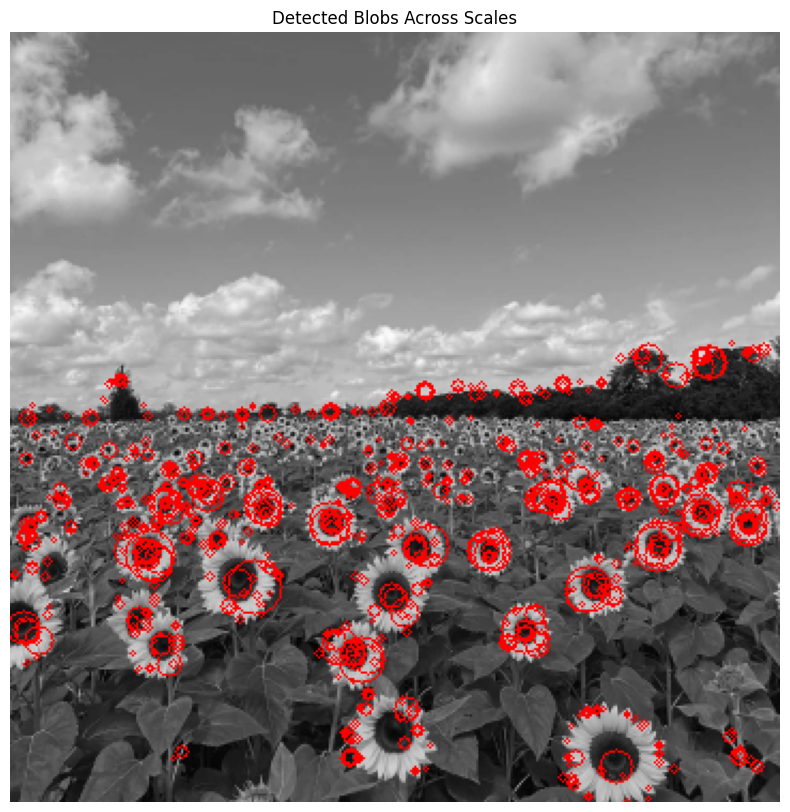

In [ ]:
# Draw all detected circles with the specified line thickness
output_image = cv.cvtColor(gray_img, cv.COLOR_GRAY2BGR)

for detection in all_detections:
    center, radius, _ = detection  # unpack center, radius, and sigma
    cv.circle(output_image, center, radius, (0, 0, 255), thickness=1)

cv.imwrite(str(RESULTS / "q1_overlay.png"), cv.cvtColor(output_image, cv.COLOR_RGB2BGR))

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output_image, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detected Blobs Across Scales')
plt.show()

## Largest Blob

In [240]:
largest_blob = max(all_detections, key=lambda x: x[1])  # x[1] is radius
center, radius, sigma = largest_blob
print(f"Largest blob at: {center} with radius {radius} and sigma {sigma:.2f}")

Largest blob at: (114, 259) with radius 13 and sigma 2.10


## Blob Detection With LoG Filter

Processing sigma = 0.71
Processing sigma = 1.04
Processing sigma = 1.38
Processing sigma = 1.71
Processing sigma = 2.05
Processing sigma = 2.38
Processing sigma = 2.72
Processing sigma = 3.05
Processing sigma = 3.39
Processing sigma = 3.72
Processing sigma = 4.06
Processing sigma = 4.39
Processing sigma = 4.73
Processing sigma = 5.06
Processing sigma = 5.40
Processing sigma = 5.73
Processing sigma = 6.07
Processing sigma = 6.40
Processing sigma = 6.74
Processing sigma = 7.07


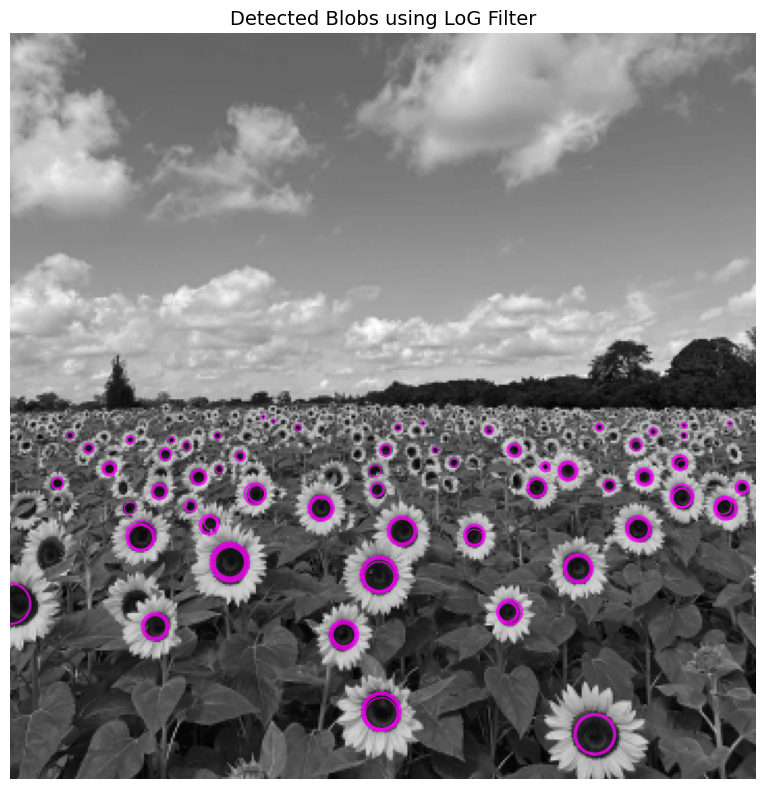

Total blobs detected: 153


<Figure size 1000x800 with 0 Axes>

In [243]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float64) / 255.0

# Create figure for plotting
plt.figure(figsize=(8, 8))
plt.imshow(gray, cmap='gray')
ax = plt.gca()

# Store all detected blobs for further processing
all_blobs = []

# Detect blobs at different sigma values
sigma_values = np.linspace(1/1.414, 10/1.414, 20)

for idx, sigma in enumerate(sigma_values):
    print(f"Processing sigma = {sigma:.2f}")

    # Create LoG filter
    hw = int(np.ceil(3 * sigma))  # Half width of the kernel
    if hw == 0:
        hw = 1

    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))
    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * \
        np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)
    LOG = sigma**2 * LOG  # Normalize by sigma^2

    # Apply filter and square the response
    img_log = cv.filter2D(gray, -1, LOG.astype(np.float64))
    img_log_squared = np.square(img_log)

    # Find local maxima above threshold
    threshold = 0.1
    local_max = np.zeros_like(img_log_squared, dtype=bool)

    # Create a kernel for local maximum detection
    kernel_size = 5  # Adjust based on expected blob size
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)

    # Find local maxima using morphological operations
    dilated = cv.dilate(img_log_squared, kernel)
    local_max = (img_log_squared == dilated) & (img_log_squared >= threshold)

    # Get coordinates of detected maxima
    coordinates = np.where(local_max)
    blob_coords = list(zip(coordinates[0], coordinates[1]))

    # Store and plot blobs
    for x, y in blob_coords:
        # Convert sigma back to actual radius
        radius = sigma * 1.414
        circle = plt.Circle((y, x), radius, color='magenta',
                            linewidth=1, fill=False, alpha=0.7)
        ax.add_patch(circle)
        all_blobs.append((x, y, radius, sigma))

# Set proper axis limits
ax.set_xlim([0, gray.shape[1]])
ax.set_ylim([gray.shape[0], 0])
plt.axis('off')
plt.title('Detected Blobs using LoG Filter', fontsize=14)
plt.tight_layout()
plt.show()
plt.savefig(RESULTS / "q1_overlay_using_LoG.png")

print(f"Total blobs detected: {len(all_blobs)}")

In [ ]:
# Detect blobs at different sigma values
sigma_values = np.linspace(1/1.414, 10/1.414, 20)

for idx, sigma in enumerate(sigma_values):
    hw = int(np.ceil(3 * sigma))  # Half width of the kernel
    if hw == 0:
        hw = 1
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))
    LOG = ((X**2 + Y**2) / (2 * sigma**2) - 1) * \
        np.exp(-(X**2 + Y**2) / (2 * sigma**2)) / (np.pi * sigma**4)
    LOG = sigma**2 * LOG  # Normalize by sigma^2
    img_log = cv.filter2D(gray, -1, LOG.astype(np.float64))  # Apply filter
    img_log_squared = np.square(img_log)
    threshold = 0.1  # Find local maxima above threshold
    local_max = np.zeros_like(img_log_squared, dtype=bool)
    kernel_size = 5  # Adjust based on expected blob size
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dilated = cv.dilate(img_log_squared, kernel)
    local_max = (img_log_squared == dilated) & (img_log_squared >= threshold)
    coordinates = np.where(local_max)  # Get coordinates of detected maxima
    blob_coords = list(zip(coordinates[0], coordinates[1]))
    # Store and plot blobs
    for x, y in blob_coords:
        radius = sigma * 1.414  # Convert sigma back to actual radius
        circle = plt.Circle((y, x), radius, color='magenta',linewidth=1, fill=False, alpha=0.7)
        ax.add_patch(circle)
        all_blobs.append((x, y, radius, sigma))